## Kaggle Login

Install kagglehub first

In [ ]:
%pip install kagglehub

In [ ]:
import kagglehub
kagglehub.login()

## Downloading the dataset

In [ ]:
import os
path = kagglehub.competition_download('nfl-big-data-bowl-2026-prediction')
print("path:", path)
print("contents:", os.listdir(path))

# EDA

## 0 - Setup

In [4]:
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = r"C:\Users\sheen\.cache\kagglehub\competitions\nfl-big-data-bowl-2026-prediction\train"
CACHE_DIR = r"./cache" # parquet cache to avoid re-parsing CSVs every run
os.makedirs(CACHE_DIR, exist_ok=True)

FIELD_LENGTH = 120.0 # in yards
FIELD_WIDTH = 53.3 # in yards

## 1 - Load + concatenate weekly files (with parquet caching)

In [5]:
def load_weekly(pattern: str, cache_name: str) -> pd.DataFrame:
    # Load all weekly CSVs matching `pattern`, concat, cache as parquet
    cache_path = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(cache_path):
        print(f"Loading cached {cache_path}")
        return pd.read_parquet(cache_path)

    files = sorted(glob.glob(os.path.join(DATA_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"No files matched {pattern} in {DATA_DIR}")

    dfs = []
    for f in files:
        week = os.path.basename(f)
        print(f"Loading {week} ...")
        df = pd.read_csv(f)
        df["week_file"] = week
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    out.to_parquet(cache_path, index=False)
    print(f"Cached to {cache_path} ({len(out):,} rows)")
    return out


input_df = load_weekly("input_2023_w*.csv", "input.parquet")
output_df = load_weekly("output_2023_w*.csv", "output.parquet")

print(input_df.shape, output_df.shape)
print(input_df.dtypes)

Loading cached ./cache\input.parquet
Loading cached ./cache\output.parquet
(4880579, 24) (562936, 7)
game_id                       int64
play_id                       int64
player_to_predict              bool
nfl_id                        int64
frame_id                      int64
play_direction               object
absolute_yardline_number      int64
player_name                  object
player_height                object
player_weight                 int64
player_birth_date            object
player_position              object
player_side                  object
player_role                  object
x                           float64
y                           float64
s                           float64
a                           float64
dir                         float64
o                           float64
num_frames_output             int64
ball_land_x                 float64
ball_land_y                 float64
week_file                    object
dtype: object


## 2 - Schema / join sanity checks

In [6]:
def sanity_checks(input_df: pd.DataFrame, output_df: pd.DataFrame) -> None:
    keys_in = input_df[["game_id", "play_id", "nfl_id"]].drop_duplicates()
    keys_out = output_df[["game_id", "play_id", "nfl_id"]].drop_duplicates()

    # a) every output player-play should exist in input
    merged = keys_out.merge(keys_in, how="left", indicator=True)
    missing_in_input = merged["_merge"].eq("right_only").sum()
    print(f"Output rows with no matching input player-play: {missing_in_input}")

    # b) players marked player_to_predict == True in input should all appear in output
    predict_keys = (
        input_df.loc[input_df["player_to_predict"], ["game_id", "play_id", "nfl_id"]]
        .drop_duplicates()
    )
    predict_vs_out = predict_keys.merge(keys_out, how="left", indicator=True)
    print(f"player_to_predict rows missing from output: "
          f"{(predict_vs_out['_merge'] == 'left_only').sum()} / {len(predict_keys):,}")

    # c) frame_id continuity in output: 1..num_frames_output per player-play
    num_frames = (
        input_df[["game_id", "play_id", "nfl_id", "num_frames_output"]]
        .drop_duplicates()
    )
    frame_counts = (
        output_df.groupby(["game_id", "play_id", "nfl_id"])["frame_id"]
        .agg(["count", "max"])
        .reset_index()
    )
    check = frame_counts.merge(num_frames, on=["game_id", "play_id", "nfl_id"], how="left")
    mismatch = check[(check["count"] != check["num_frames_output"]) |
                      (check["max"] != check["num_frames_output"])]
    print(f"Player-plays with frame_id count/max mismatch vs num_frames_output: "
          f"{len(mismatch)} / {len(check):,}")

    # d) coordinate range sanity
    for col_df, name in [(input_df, "input"), (output_df, "output")]:
        x_bad = ((col_df["x"] < -2) | (col_df["x"] > FIELD_LENGTH + 2)).sum() # add buffer/tolerance of ±2
        y_bad = ((col_df["y"] < -2) | (col_df["y"] > FIELD_WIDTH + 2)).sum() # add buffer/tolerance of ±2
        print(f"[{name}] x out of [0,{FIELD_LENGTH}] (±2 buffer): {x_bad}, "
              f"y out of [0,{FIELD_WIDTH}] (±2 buffer): {y_bad}")

    # e) duplicate rows
    dup_in = input_df.duplicated(subset=["game_id", "play_id", "nfl_id", "frame_id"]).sum()
    dup_out = output_df.duplicated(subset=["game_id", "play_id", "nfl_id", "frame_id"]).sum()
    print(f"Duplicate (game,play,nfl,frame) rows -> input: {dup_in}, output: {dup_out}")

    # f) frame-to-frame teleport check (large jumps that suggest data errors)
    tmp = output_df.sort_values(["game_id", "play_id", "nfl_id", "frame_id"]).copy()
    tmp["dx"] = tmp.groupby(["game_id", "play_id", "nfl_id"])["x"].diff()
    tmp["dy"] = tmp.groupby(["game_id", "play_id", "nfl_id"])["y"].diff()
    tmp["step_dist"] = np.sqrt(tmp["dx"] ** 2 + tmp["dy"] ** 2)

    # >1.5 yards in 1/10s = 15 yd/s, near the fastest humans ever recorded -> suspicious
    suspicious = tmp["step_dist"] > 1.5
    print(f"Frame-to-frame steps > 1.5 yd (15 yd/s): {suspicious.sum()} "
          f"({suspicious.mean()*100:.3f}% of steps)")


sanity_checks(input_df, output_df)

Output rows with no matching input player-play: 0
player_to_predict rows missing from output: 0 / 46,045
Player-plays with frame_id count/max mismatch vs num_frames_output: 0 / 46,045
[input] x out of [0,120.0] (±2 buffer): 0, y out of [0,53.3] (±2 buffer): 0
[output] x out of [0,120.0] (±2 buffer): 0, y out of [0,53.3] (±2 buffer): 0
Duplicate (game,play,nfl,frame) rows -> input: 0, output: 0
Frame-to-frame steps > 1.5 yd (15 yd/s): 5 (0.001% of steps)


## 3 - Normalize play direction so every play "attacks" the same way

In [7]:
def normalize_direction(df: pd.DataFrame) -> pd.DataFrame:
    
    # Flip x, y, o, dir for plays moving left so all plays go left->right
    
    df = df.copy()
    left = df["play_direction"] == "left"

    df.loc[left, "x"] = FIELD_LENGTH - df.loc[left, "x"]
    df.loc[left, "y"] = FIELD_WIDTH - df.loc[left, "y"]

    for angle_col in ["o", "dir"]:
        if angle_col in df.columns:
            df.loc[left, angle_col] = (df.loc[left, angle_col] + 180) % 360

    return df


input_norm = normalize_direction(input_df)
if "ball_land_x" in input_norm.columns:
    left = input_df["play_direction"] == "left"
    input_norm.loc[left, "ball_land_x"] = FIELD_LENGTH - input_norm.loc[left, "ball_land_x"]
    input_norm.loc[left, "ball_land_y"] = FIELD_WIDTH - input_norm.loc[left, "ball_land_y"]

# output needs the same flip, joined on play_direction from input
play_dir_lookup = input_df[["game_id", "play_id", "play_direction"]].drop_duplicates()
output_norm = output_df.merge(play_dir_lookup, on=["game_id", "play_id"], how="left")
output_norm = normalize_direction(output_norm)


# unflip and reverse the predictions. run this last.
def unflip_predictions(pred_df: pd.DataFrame, play_dir_lookup: pd.DataFrame) -> pd.DataFrame:
    
    # Reverse normalize_direction() on model predictions.
    merged = pred_df.merge(play_dir_lookup, on=["game_id", "play_id"], how="left")
    if merged["play_direction"].isna().any():
        n_missing = merged["play_direction"].isna().sum()
        raise ValueError(
            f"{n_missing} prediction rows have no matching play_direction — "
            "check the join keys before submitting."
        )
    return normalize_direction(merged).drop(columns=["play_direction"])

# lil sanity check: flip then unflip should return the original x, y exactly
def _test_flip_unflip_roundtrip(input_df: pd.DataFrame) -> None:
    sample = input_df[["game_id", "play_id", "nfl_id", "x", "y", "play_direction"]].head(5000).copy()
    dir_lookup = sample[["game_id", "play_id", "play_direction"]].drop_duplicates()

    flipped = normalize_direction(sample)
    roundtrip = unflip_predictions(
        flipped[["game_id", "play_id", "nfl_id", "x", "y"]], dir_lookup
    )

    x_match = np.allclose(sample["x"].values, roundtrip["x"].values, atol=1e-9)
    y_match = np.allclose(sample["y"].values, roundtrip["y"].values, atol=1e-9)
    assert x_match and y_match, "Flip -> unflip round-trip did NOT recover original x, y!"
    print("Flip/unflip round-trip check passed: original == unflip(flip(original))")


_test_flip_unflip_roundtrip(input_df)

Flip/unflip round-trip check passed: original == unflip(flip(original))


## 4 - ***num_frames_output*** distribution (our prediction horizon)

count    14108.000000
mean        11.366601
std          5.147501
min          5.000000
25%          8.000000
50%         10.000000
75%         13.000000
max         94.000000
Name: num_frames_output, dtype: float64


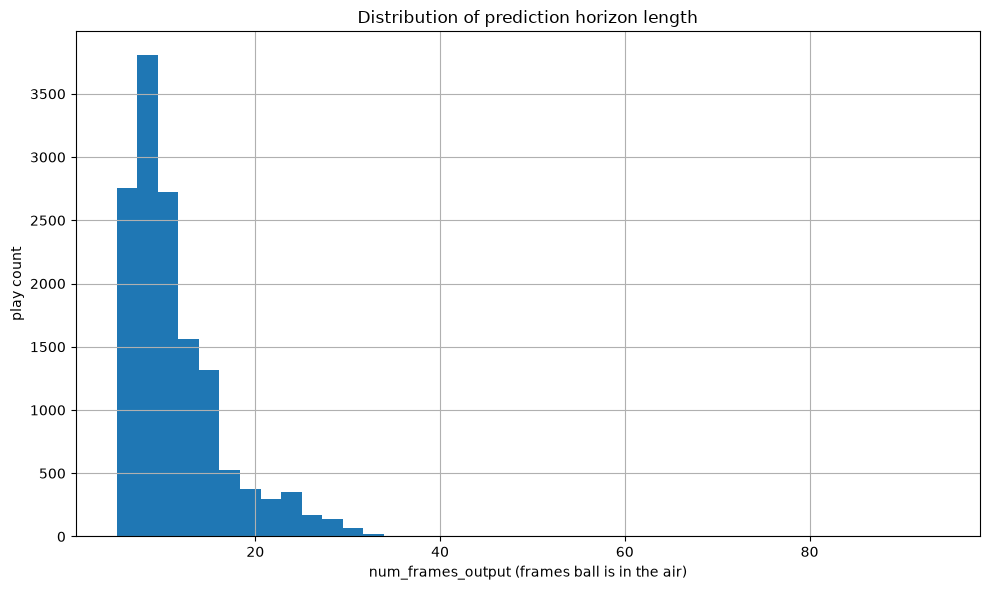

In [8]:
horizon = (
    input_df[["game_id", "play_id", "num_frames_output"]]
    .drop_duplicates()["num_frames_output"]
)
print(horizon.describe())

fig, ax = plt.subplots()
horizon.hist(bins=40, ax=ax)
ax.set_xlabel("num_frames_output (frames ball is in the air)")
ax.set_ylabel("play count")
ax.set_title("Distribution of prediction horizon length")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "horizon_hist.png"), dpi=120)
plt.show()

## 5 - Displacement by ***player_role***

During the time the ball is in the air, how much do different types of players actually move?

**net_displacement** = *How far away did they end up from where they started?*

**path_length** = *How much total ground did they travel?*

                   net_displacement                                          \
                              count      mean       std       min       25%   
player_role                                                                   
Defensive Coverage          31937.0  5.734746  4.568965  0.022361  2.650887   
Targeted Receiver           14108.0  6.074466  5.063940  0.010000  2.821790   

                                                  path_length            \
                         50%       75%        max       count      mean   
player_role                                                               
Defensive Coverage  4.387824  7.252069  30.410769     31937.0  5.931614   
Targeted Receiver   4.673264  7.434904  32.485758     14108.0  6.173295   

                                                                      \
                         std       min       25%       50%       75%   
player_role                                                            
Defensive Co

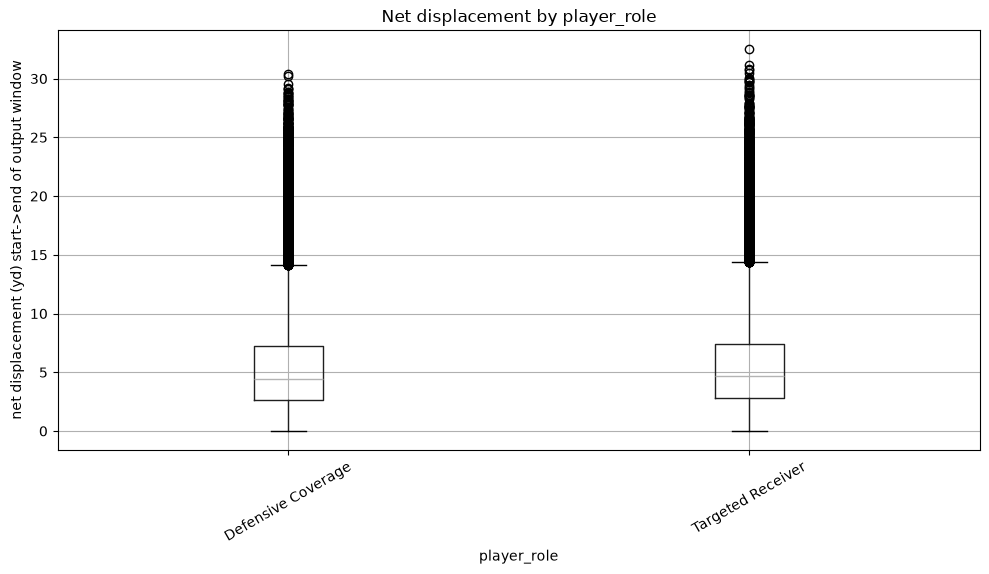

In [9]:
def displacement_by_role(input_df: pd.DataFrame, output_norm: pd.DataFrame) -> pd.DataFrame:
    role_lookup = (
        input_df[["game_id", "play_id", "nfl_id", "player_role", "player_position"]]
        .drop_duplicates()
    )

    traj = output_norm.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])

    # group by the SAME 3 keys for both net_disp and total_path so their
    # indexes line up -- player_role gets attached afterward via merge,
    # not included in the groupby (it doesn't vary within a player-play anyway)
    grp = traj.groupby(["game_id", "play_id", "nfl_id"])
    first = grp.first()
    last = grp.last()

    net_disp = np.sqrt((last["x"] - first["x"]) ** 2 + (last["y"] - first["y"]) ** 2)
    net_disp.name = "net_displacement"

    # total path length (sum of frame-to-frame steps)
    traj["dx"] = traj.groupby(["game_id", "play_id", "nfl_id"])["x"].diff()
    traj["dy"] = traj.groupby(["game_id", "play_id", "nfl_id"])["y"].diff()
    traj["step"] = np.sqrt(traj["dx"] ** 2 + traj["dy"] ** 2)
    total_path = traj.groupby(["game_id", "play_id", "nfl_id"])["step"].sum()
    total_path.name = "path_length"

    summary = pd.concat([net_disp, total_path], axis=1).reset_index()
    summary = summary.merge(role_lookup, on=["game_id", "play_id", "nfl_id"], how="left")

    return summary


disp_summary = displacement_by_role(input_df, output_norm)
print(disp_summary.groupby("player_role")[["net_displacement", "path_length"]].describe())

fig, ax = plt.subplots()
disp_summary.boxplot(column="net_displacement", by="player_role", ax=ax, rot=30)
ax.set_ylabel("net displacement (yd) start->end of output window")
plt.suptitle("")
plt.title("Net displacement by player_role")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "displacement_by_role.png"), dpi=120)
plt.show()

### Findings
Average **net_displacement** for each player role:

- Defensive Coverage: **5.7 yards**
- Targeted Receiver: **6.1 yards**

Average **path_length** for each player role:

- Defensive Coverage: **6 yards**
- Targeted Reciever: **6.2 yards**

## 6 - Distance-to-ball-landing-spot over time, by role

As the ball gets closer to where it's going to land, 

do the receiver and defender **actually move toward** that landing spot?

How do players move relative to the ball's eventual landing location?

**Calculation**:

How many yards away is the receiver from that landing spot?

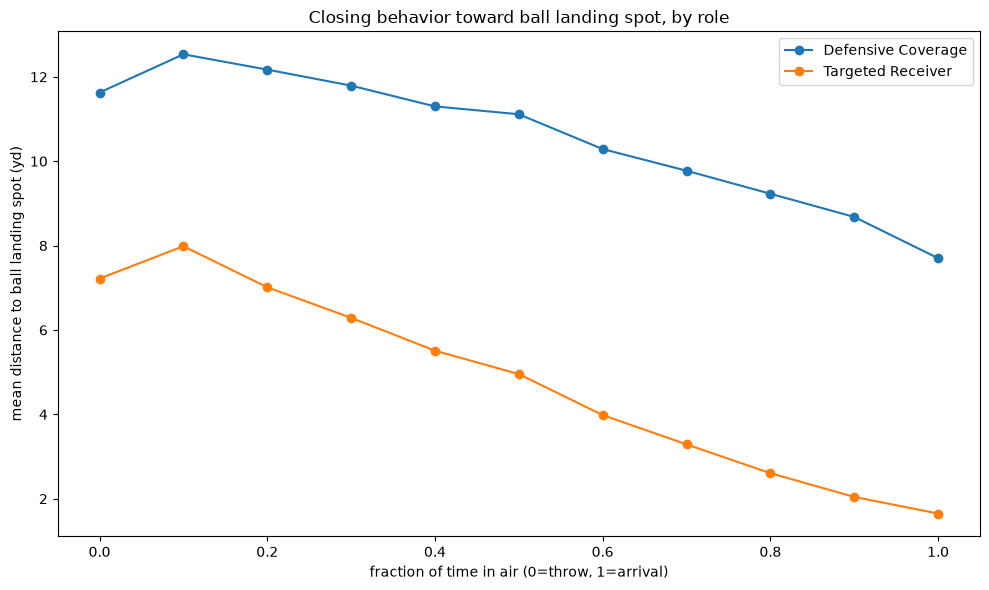

In [10]:
def distance_to_landing_over_time(input_norm: pd.DataFrame, output_norm: pd.DataFrame) -> pd.DataFrame:

    ball_lookup = (
        input_norm[["game_id", "play_id", "ball_land_x", "ball_land_y"]]
        .drop_duplicates()
    )
    role_lookup = (
        input_norm[["game_id", "play_id", "nfl_id", "player_role"]]
        .drop_duplicates()
    )
 
    traj = output_norm.merge(ball_lookup, on=["game_id", "play_id"], how="left")
    traj = traj.merge(role_lookup, on=["game_id", "play_id", "nfl_id"], how="left")
 
    traj["dist_to_land"] = np.sqrt(
        (traj["x"] - traj["ball_land_x"]) ** 2 + (traj["y"] - traj["ball_land_y"]) ** 2
    )
 
    # normalizing frame_id to a fraction of each play's horizon so plays of different lengths can be averaged together
    traj["frame_frac"] = traj.groupby(["game_id", "play_id", "nfl_id"])["frame_id"].transform(
        lambda s: (s - 1) / max(s.max() - 1, 1)
    )
    traj["frame_bucket"] = (traj["frame_frac"] * 10).round().astype(int)  # 0..10
 
    curve = (
        traj.groupby(["player_role", "frame_bucket"])["dist_to_land"]
        .mean()
        .reset_index()
    )
    return curve
 
 
dist_curve = distance_to_landing_over_time(input_norm, output_norm)
 
fig, ax = plt.subplots()
for role, sub in dist_curve.groupby("player_role"):
    ax.plot(sub["frame_bucket"] / 10.0, sub["dist_to_land"], marker="o", label=role)
ax.set_xlabel("fraction of time in air (0=throw, 1=arrival)")
ax.set_ylabel("mean distance to ball landing spot (yd)")
ax.set_title("Closing behavior toward ball landing spot, by role")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "dist_to_landing_by_role.png"), dpi=120)
plt.show()

### Findings
<u>Targeted Receivers</u> tend to be **closer** to the eventual landing spot than the defenders.

## 6.5 - Verify `dir` angle convention

Validating the `dir` angle convention by comparing movement implied by `s` and `dir` against the observed frame-to-frame movement in **x/y**.

**Interpretation:**

- 0° points along +Y.
- 90° points toward +X.
- 180° points along −Y.
- 270° points toward −X.
- Displacement components are calculated using **sin(dir)** for **X** and **cos(dir)** for **Y**.

The following code is for verifying our `dir` interpretation. We'll observe some frame-to-frame movements, and check if it's consistent with our interpretation of the `dir` feature.

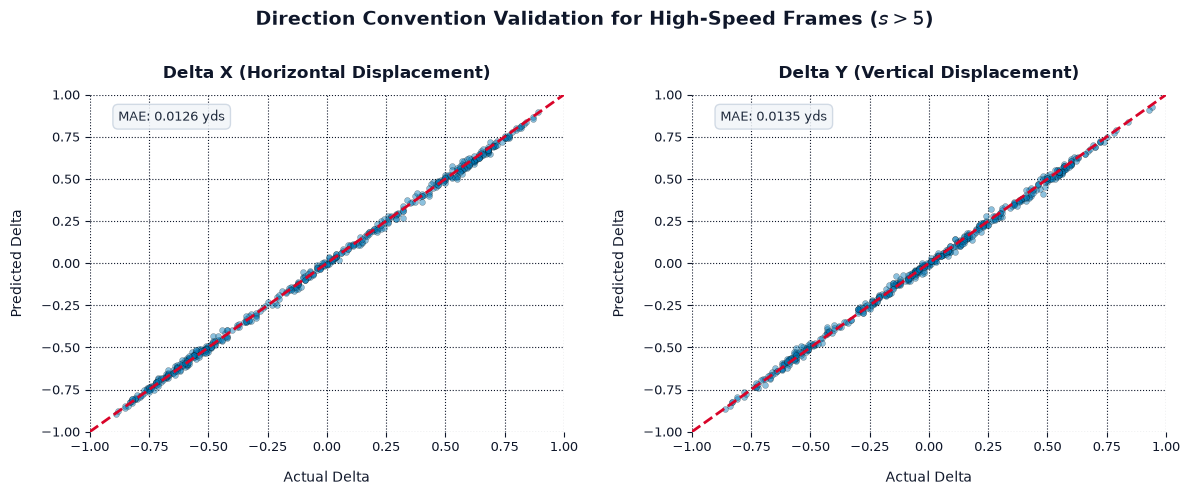

In [11]:
fast_frames = input_df[input_df["s"] > 5].sample(500, random_state=42)

df_sorted = input_df.sort_values(["game_id", "play_id", "nfl_id", "frame_id"]).copy()

df_sorted["actual_dx"] = df_sorted.groupby(["game_id", "play_id", "nfl_id"])["x"].shift(-1) - df_sorted["x"]
df_sorted["actual_dy"] = df_sorted.groupby(["game_id", "play_id", "nfl_id"])["y"].shift(-1) - df_sorted["y"]

results_df = df_sorted.loc[fast_frames.index].dropna(subset=["actual_dx", "actual_dy"]).copy()

dir_rad = np.deg2rad(results_df["dir"])
dt = 0.1
results_df["pred_dx"] = results_df["s"] * np.sin(dir_rad) * dt
results_df["pred_dy"] = results_df["s"] * np.cos(dir_rad) * dt

plt.style.use("default")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="#FFFFFF")

metrics = [("actual_dx", "pred_dx", r"Delta X (Horizontal Displacement)"),
           ("actual_dy", "pred_dy", r"Delta Y (Vertical Displacement)")]

for ax, (actual_col, pred_col, title) in zip(axes, metrics):
    ax.set_facecolor("#FFFFFF")
    
    ax.scatter(
        results_df[actual_col], 
        results_df[pred_col], 
        color="#0077B6",
        alpha=0.45,
        s=18,
        linewidths=0.3, 
        edgecolors="#000000",
        zorder=3
    )
    
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    lims = [-1, 1]
    ax.plot(lims, lims, color="#D90429", linestyle="--", linewidth=2, zorder=4)
    
    mae = np.mean(np.abs(results_df[actual_col] - results_df[pred_col]))
    ax.text(
        0.06, 0.923, f"MAE: {mae:.4f} yds", transform=ax.transAxes, 
        color="#1E293B", fontsize=9.5, fontweight=400,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#F1F5F9", edgecolor="#CBD5E1", alpha=0.85)
    )

    ax.set_title(title, fontsize=12, fontweight="bold", color="#0F172A", pad=12, loc="center")
    ax.set_xlabel(f"Actual {title.split()[0]}", fontsize=10, color="#0F172A", labelpad=12)
    ax.set_ylabel(f"Predicted {title.split()[0]}", fontsize=10, color="#0F172A", labelpad=12)
    
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
        
    ax.grid(True, color="#0F172A", linestyle=":", linewidth=0.8, zorder=1)
    ax.tick_params(colors="#0F172A", labelsize=9)

fig.suptitle("Direction Convention Validation for High-Speed Frames ($s > 5$)", 
             fontsize=14, fontweight="bold", color="#0F172A", x=0.5, ha="center")

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(wspace=0.27)
plt.show()

### Finding

The very low **MAE** for both **Delta X** (0.0126 yds) and **Delta Y** (0.0135 yds) supports the assumed `dir` angle convention.

## 7 - Baseline error floor: constant-velocity extrapolation

Before we build a fancy ML model, how well can a really simple model already do?

*Here's the level of performance we get from this basic approach. A useful ML model should ideally do better.*

Quantifying this BEFORE building anything fancier. It tells us how much of the problem is ***"easy"*** physics vs. genuine decision-making.

The formula: **Starting position** + **movement** × **time** = **predicted future position**

Constant-velocity baseline mean position error (yd) by role:
                        mean    median       std
player_role                                     
Defensive Coverage  1.521097  0.796939  2.059224
Targeted Receiver   1.129392  0.559529  1.641422


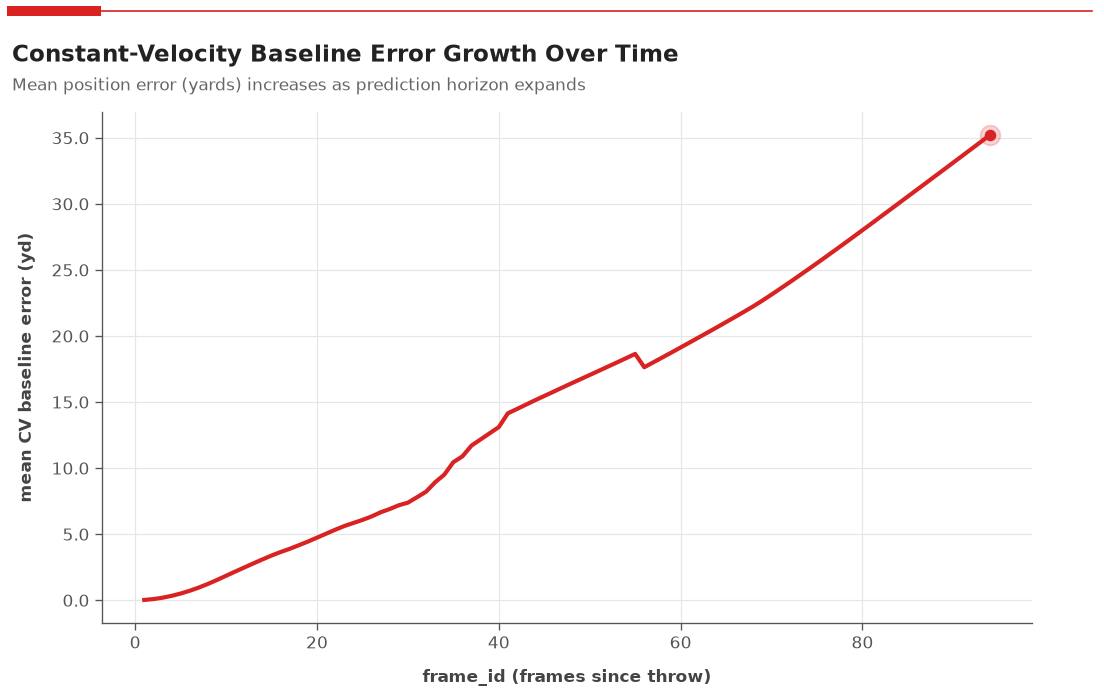

In [12]:
def constant_velocity_baseline(input_norm: pd.DataFrame, output_norm: pd.DataFrame) -> pd.DataFrame:
    
    # For each player-play, extrapolate x,y forward using last-frame s, dir
    
    last_input = (
        input_norm.sort_values(["game_id", "play_id", "nfl_id", "frame_id"])
        .groupby(["game_id", "play_id", "nfl_id"])
        .last()
        .reset_index()
    )

    dir_rad = np.deg2rad(last_input["dir"])
    last_input["vx"] = last_input["s"] * np.sin(dir_rad)
    last_input["vy"] = last_input["s"] * np.cos(dir_rad)

    traj = output_norm.merge(
        last_input[["game_id", "play_id", "nfl_id", "x", "y", "vx", "vy"]],
        on=["game_id", "play_id", "nfl_id"],
        suffixes=("", "_start"),
    )
    traj["t"] = traj["frame_id"] * 0.1  # seconds since throw (frame 1 = 0.1s)
    traj["pred_x"] = traj["x_start"] + traj["vx"] * traj["t"]
    traj["pred_y"] = traj["y_start"] + traj["vy"] * traj["t"]

    traj["err"] = np.sqrt((traj["x"] - traj["pred_x"]) ** 2 + (traj["y"] - traj["pred_y"]) ** 2)
    return traj


cv_baseline = constant_velocity_baseline(input_norm, output_norm)

print("Constant-velocity baseline mean position error (yd) by role:")
role_lookup = input_norm[["game_id", "play_id", "nfl_id", "player_role"]].drop_duplicates()
cv_baseline = cv_baseline.merge(role_lookup, on=["game_id", "play_id", "nfl_id"], how="left")
print(cv_baseline.groupby("player_role")["err"].agg(["mean", "median", "std"]))

err_by_frame = cv_baseline.groupby("frame_id")["err"].mean()

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
fig.subplots_adjust(top=0.82)

line_color = "#d92323"
ax.plot(err_by_frame.index, err_by_frame.values, color=line_color, linewidth=2.5, zorder=3)

last_x = err_by_frame.index[-1]
last_y = err_by_frame.values[-1]
ax.scatter(last_x, last_y, color=line_color, s=140, alpha=0.2, zorder=4)
ax.scatter(last_x, last_y, color=line_color, s=35, zorder=5)

ax.grid(color='#e6e6e6', linestyle='-', linewidth=0.7, zorder=1)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.1f}'))
ax.tick_params(axis='both', colors='#555555', labelsize=10, length=4)
ax.set_xlabel("frame_id (frames since throw)", color='#444444', fontweight='bold', fontsize=10, labelpad=10)
ax.set_ylabel("mean CV baseline error (yd)", color='#444444', fontweight='bold', fontsize=10, labelpad=10)

fig.add_artist(mlines.Line2D([0.05, 0.12], [0.96, 0.96], color='#d92323', linewidth=6, transform=fig.transFigure))
fig.add_artist(mlines.Line2D([0.12, 0.95], [0.96, 0.96], color='#d92323', linewidth=1, transform=fig.transFigure))

fig.text(0.05, 0.89, "Constant-Velocity Baseline Error Growth Over Time", 
         fontsize=14, fontweight='bold', color='#222222')
fig.text(0.05, 0.85, "Mean position error (yards) increases as prediction horizon expands", 
         fontsize=10, color='#666666')

plt.savefig(os.path.join(CACHE_DIR, "cv_baseline_error.png"), dpi=120, bbox_inches='tight')
plt.show()

### Check sample size at long prediction horizons.
Seeing how few rows contribute past ~frame 60.

Very small counts can make the error curve noisy at high frame_id values.

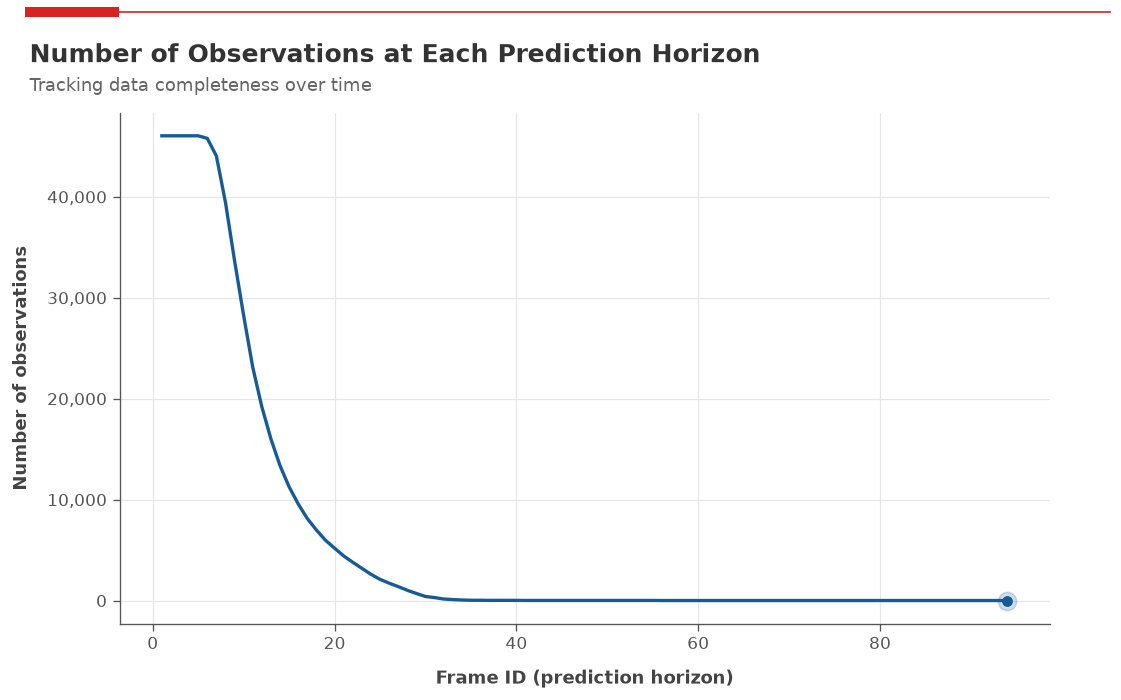

In [13]:
frame_counts = cv_baseline.groupby("frame_id").size()

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

fig.subplots_adjust(top=0.82)

line_color = "#175b96"
ax.plot(frame_counts.index, frame_counts.values, color=line_color, linewidth=2, zorder=3)

last_x = frame_counts.index[-1]
last_y = frame_counts.values[-1]
ax.scatter(last_x, last_y, color=line_color, s=120, alpha=0.2, zorder=4) 
ax.scatter(last_x, last_y, color=line_color, s=30, zorder=5)             

ax.grid(color='#e6e6e6', linestyle='-', linewidth=0.7, zorder=1)
ax.set_axisbelow(True) 


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#555555')
ax.spines['bottom'].set_color('#555555')

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='both', colors='#555555', labelsize=10, length=4)

ax.set_xlabel("Frame ID (prediction horizon)", color='#444444', fontweight='bold', fontsize=11, labelpad=10)
ax.set_ylabel("Number of observations", color='#444444', fontweight='bold', fontsize=11, labelpad=10)


fig.add_artist(mlines.Line2D([0.05, 0.12], [0.96, 0.96], color='#d92323', linewidth=6, transform=fig.transFigure))
fig.add_artist(mlines.Line2D([0.12, 0.95], [0.96, 0.96], color='#d92323', linewidth=1, transform=fig.transFigure))


fig.text(0.05, 0.89, "Number of Observations at Each Prediction Horizon", 
         fontsize=15, fontweight='bold', color='#333333')
fig.text(0.05, 0.85, "Tracking data completeness over time",
         fontsize=11, color='#666666')

plt.show()

## 8 - Single-play trajectory visualization

### Representative play selection

Selecting a representative play before visualizing it, one that has all the following roles present: 
- Receiver
- Defender
- Passer
- Other route runner

AND with its horizon close to the **median** (not an outlier-long play)

In [14]:
role_sets = (
    input_norm.groupby(["game_id", "play_id"])["player_role"]
    .apply(lambda s: set(s.unique()))
)
all_roles = {"Targeted Receiver", "Defensive Coverage", "Passer", "Other Route Runner"}
plays_with_all_roles = role_sets[role_sets.apply(lambda s: all_roles.issubset(s))].index

horizon_lookup = input_norm[["game_id", "play_id", "num_frames_output"]].drop_duplicates()
median_horizon = horizon_lookup["num_frames_output"].median()

candidates = horizon_lookup[
    horizon_lookup.set_index(["game_id", "play_id"]).index.isin(plays_with_all_roles)
].copy()
candidates["dist_from_median"] = (candidates["num_frames_output"] - median_horizon).abs()
representative_play = candidates.sort_values("dist_from_median").iloc[0]

REP_GAME_ID = int(representative_play.game_id)
REP_PLAY_ID = int(representative_play.play_id)
print(f"Representative play selected: game {REP_GAME_ID}, play {REP_PLAY_ID}, "
      f"horizon {int(representative_play.num_frames_output)} frames "
      f"(median is {median_horizon})")

Representative play selected: game 2023111204, play 3512, horizon 10 frames (median is 10.0)


### 8.1 - Static trajectory plot

Static visualization of the full selected play: **pre-throw route** + **post-throw movement**

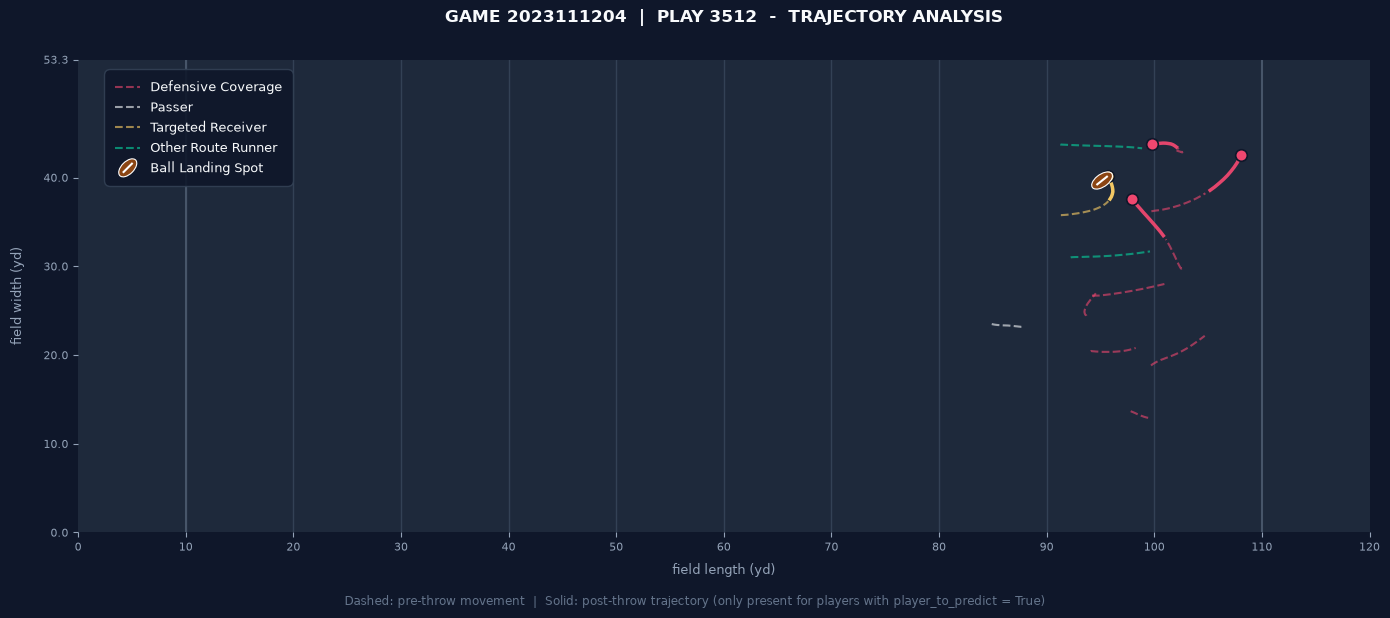

In [15]:
# Helper to draw a vector football for the legend and as the marker

def draw_football(center_x, center_y, width, height, transform, zorder=1):
    football = Ellipse((center_x, center_y), width=width, height=height, angle=45,
                        facecolor="#8B4513", edgecolor="#FFFFFF", linewidth=0.8,
                        transform=transform, zorder=zorder)

    laces_dx = width * 0.1875
    laces_dy = height * 0.333
    laces = Line2D([center_x - laces_dx, center_x + laces_dx],
                   [center_y - laces_dy, center_y + laces_dy],
                   color="#FFFFFF", linewidth=1.5, transform=transform, zorder=zorder + 1)

    return football, laces

class FootballLegendHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        center_x = xdescent + width / 2.0
        center_y = ydescent + height / 2.0
        football, laces = draw_football(center_x, center_y, width=16, height=9, transform=trans)
        return [football, laces]

# The actual plot
def plot_play(game_id: int, play_id: int, input_norm: pd.DataFrame, output_norm: pd.DataFrame, 
              save_path: str | None = None) -> None: 
    
    inp = input_norm[(input_norm.game_id == game_id) & (input_norm.play_id == play_id)] 
    out = output_norm[(output_norm.game_id == game_id) & (output_norm.play_id == play_id)] 

    role_lookup = inp[["nfl_id", "player_role"]].drop_duplicates().set_index("nfl_id") 
    ball_land = inp[["ball_land_x", "ball_land_y"]].iloc[0] 

    fig, ax = plt.subplots(figsize=(14, 6.5), facecolor="#0F172A") 
    ax.set_facecolor("#1E293B") 
    ax.set_xlim(0, FIELD_LENGTH) 
    ax.set_ylim(0, FIELD_WIDTH) 

    for x in range(10, 110, 10): 
        ax.axvline(x, color="#334155", linestyle="-", linewidth=1, zorder=1) 
    ax.axvline(10, color="#475569", linestyle="-", linewidth=1.5, zorder=1) 
    ax.axvline(110, color="#475569", linestyle="-", linewidth=1.5, zorder=1) 

    color_map = { 
        "Targeted Receiver": "#FFD166", 
        "Defensive Coverage": "#EF476F", 
        "Passer": "#F8FAFC", 
        "Other Route Runner": "#06D6A0", 
    } 

    all_ids = sorted(set(inp["nfl_id"]).union(out["nfl_id"])) 
    for nfl_id in all_ids: 
        role = role_lookup.loc[nfl_id, "player_role"] if nfl_id in role_lookup.index else "Other" 
        c = color_map.get(role, "#94A3B8") 

        pre = inp[inp.nfl_id == nfl_id].sort_values("frame_id") 
        if len(pre): 
            ax.plot(pre["x"], pre["y"], linestyle="--", linewidth=1.5, color=c, alpha=0.6, label=role, zorder=3) 

        post = out[out.nfl_id == nfl_id].sort_values("frame_id") 
        if len(post): 
            ax.plot(post["x"], post["y"], linestyle="-", linewidth=2.5, color=c, alpha=0.95, zorder=4) 
            ax.scatter(post["x"].iloc[-1], post["y"].iloc[-1], color=c, edgecolor="#0F172A",  
                       s=70, linewidth=1.2, zorder=5) 

    ball_x = ball_land["ball_land_x"] 
    ball_y = ball_land["ball_land_y"] 
    football, laces = draw_football(ball_x, ball_y, width=2.4, height=1.3, transform=ax.transData, zorder=6)
    ax.add_patch(football)
    ax.add_line(laces)

    ball_handle = ax.plot([], [], label="Ball Landing Spot")[0]

    ax.set_title(f"GAME {game_id}  |  PLAY {play_id}  -  TRAJECTORY ANALYSIS",  
                 fontsize=12, fontweight="bold", color="#F8FAFC", loc="center", pad=27) 

    for spine in ax.spines.values(): 
        spine.set_visible(False) 

    ax.set_xticks(range(0, 121, 10))
    ax.set_yticks([0, 10, 20, 30, 40, 53.3])
    ax.tick_params(axis="both", colors="#94A3B8", labelsize=8)
    ax.set_xlabel("field length (yd)", color="#94A3B8", fontsize=9, labelpad=7)
    ax.set_ylabel("field width (yd)", color="#94A3B8", fontsize=9, labelpad=14)

    handles, labels = ax.get_legend_handles_labels() 
    uniq = dict(zip(labels, handles)) 
    legend = ax.legend(uniq.values(), uniq.keys(), loc="upper left",
                       bbox_to_anchor=(0.02, 0.98),
                       facecolor="#0F172A",  
                       edgecolor="#334155", labelcolor="#F8FAFC", fontsize=9, framealpha=0.9,
                       handler_map={ball_handle: FootballLegendHandler()})
    legend.get_frame().set_boxstyle("round,pad=0.5") 

    fig.text(0.5, 0.02, 
             "Dashed: pre-throw movement  |  Solid: post-throw trajectory "
             "(only present for players with player_to_predict = True)", 
             ha="center", fontsize=8.5, color="#64748B") 

    plt.tight_layout(rect=[0, 0.04, 1, 0.96]) 
    fig.subplots_adjust(wspace=0.35) 

    if save_path: 
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor()) 
    plt.show() 

plot_play(REP_GAME_ID, REP_PLAY_ID, input_norm, output_norm, 
          save_path=os.path.join(CACHE_DIR, "representative_play.png"))

### 8.2 - Simple animation

Animated visualization of **post-throw frames** of the selected play

In [16]:
def animate_play(game_id: int, play_id: int, input_norm: pd.DataFrame, output_norm: pd.DataFrame,
                  save_path: str = None):
    out = output_norm[(output_norm.game_id == game_id) & (output_norm.play_id == play_id)]
    inp = input_norm[(input_norm.game_id == game_id) & (input_norm.play_id == play_id)]
    role_lookup = inp[["nfl_id", "player_role"]].drop_duplicates().set_index("nfl_id")
    ball_land = inp[["ball_land_x", "ball_land_y"]].iloc[0]

    color_map = {
        "Targeted Receiver": "#FFD166",
        "Defensive Coverage": "#EF476F",
        "Passer": "#F8FAFC",
        "Other Route Runner": "#06D6A0",
    }

    ball_x = ball_land["ball_land_x"]
    ball_y = ball_land["ball_land_y"]

    frames = sorted(out["frame_id"].unique())
    fig, ax = plt.subplots(figsize=(14, 6.5), facecolor="#0F172A")

    def draw(frame_id):
        ax.clear()
        ax.set_facecolor("#1E293B")
        ax.set_xlim(0, FIELD_LENGTH)
        ax.set_ylim(0, FIELD_WIDTH)

        for x in range(10, 110, 10):
            ax.axvline(x, color="#334155", linestyle="-", linewidth=1, zorder=1)
        ax.axvline(10, color="#475569", linestyle="-", linewidth=1.5, zorder=1)
        ax.axvline(110, color="#475569", linestyle="-", linewidth=1.5, zorder=1)

        snap = out[out.frame_id == frame_id]
        for _, row in snap.iterrows():
            role = role_lookup.loc[row.nfl_id, "player_role"] if row.nfl_id in role_lookup.index else "Other"
            c = color_map.get(role, "#94A3B8")
            ax.scatter(row.x, row.y, color=c, s=80, edgecolor="#0F172A", linewidth=1.2, zorder=5, label=role)

        football, laces = draw_football(ball_x, ball_y, width=2.4, height=1.3, transform=ax.transData, zorder=6)
        ax.add_patch(football)
        ax.add_line(laces)
        ball_handle = ax.plot([], [], label="Ball Landing Spot")[0]

        ax.set_title(f"GAME {game_id}  |  PLAY {play_id}  -  FRAME {frame_id}",
                     fontsize=12, fontweight="bold", color="#F8FAFC", loc="center", pad=27)

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.set_xticks(range(0, 121, 10))
        ax.set_yticks([0, 10, 20, 30, 40, 53.3])
        ax.tick_params(axis="both", colors="#94A3B8", labelsize=8)
        ax.set_xlabel("field length (yd)", color="#94A3B8", fontsize=9, labelpad=7)
        ax.set_ylabel("field width (yd)", color="#94A3B8", fontsize=9, labelpad=14)

        handles, labels = ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        legend = ax.legend(uniq.values(), uniq.keys(), loc="upper left",
                           bbox_to_anchor=(0.02, 0.98),
                           facecolor="#0F172A", edgecolor="#334155",
                           labelcolor="#F8FAFC", fontsize=9, framealpha=0.9,
                           handler_map={ball_handle: FootballLegendHandler()})
        legend.get_frame().set_boxstyle("round,pad=0.5")

    anim = FuncAnimation(fig, draw, frames=frames, interval=100)
    fig.patch.set_facecolor("#0F172A")
    if save_path:
        anim.save(save_path, writer="pillow", fps=10, savefig_kwargs={"facecolor": fig.get_facecolor()})
    plt.close(fig)
    return anim

from IPython.display import HTML
anim = animate_play(REP_GAME_ID, REP_PLAY_ID, input_norm, output_norm)
HTML(anim.to_jshtml())

## 9 - Weekly distribution shift check

 (for our held-out validation split)

In [ ]:
def week_of(fname: str) -> int:
    return int(fname.split("_w")[-1].split(".")[0])


input_df["week"] = input_df["week_file"].apply(week_of)
weekly_stats = input_df.groupby("week").agg(
    n_plays=("play_id", "nunique"),
    mean_speed=("s", "mean"),
    mean_yardline=("absolute_yardline_number", "mean"),
).reset_index()
print(weekly_stats)

fig, ax = plt.subplots()
ax.plot(weekly_stats["week"], weekly_stats["n_plays"], marker="o")
ax.set_xlabel("week")
ax.set_ylabel("scored plays")
ax.set_title("Play volume per week (sanity check for shift / gaps)")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "weekly_play_volume.png"), dpi=120)
plt.show()

print("\nDone. PNGs written to", CACHE_DIR)